## Breast Cancer Classification

## 1. Load & Clean

In [1]:
!kaggle datasets download uciml/breast-cancer-wisconsin-data -p data/breast_cancer --unzip

Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
License(s): CC-BY-NC-SA-4.0
100%|███████████████████████████████████████| 48.6k/48.6k [00:00<00:00, 262kB/s]



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import LabelEncoder


In [3]:
df = pd.read_csv('data/breast_cancer/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 2. EDA

In [4]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [5]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [6]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [7]:
df.drop(columns=['Unnamed: 32'], inplace=True)

In [8]:
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Number of samples: 569
Number of features before encoding: 30
diagnosis
B    357
M    212
Name: count, dtype: int64


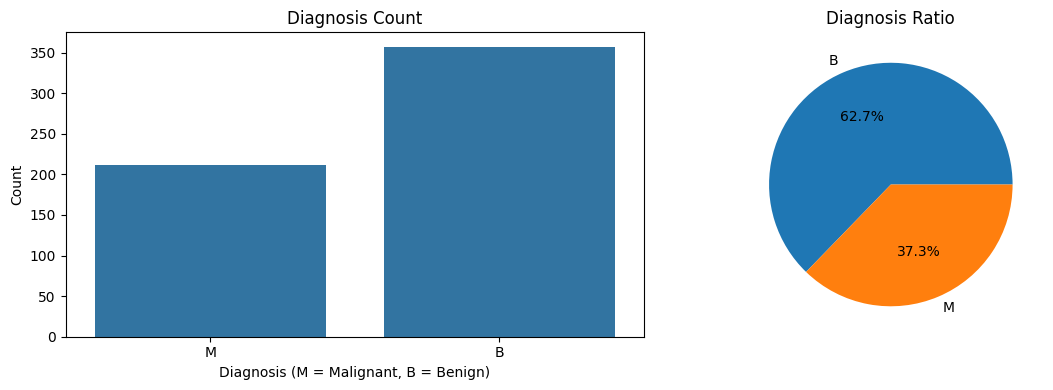

In [9]:
# Dataset summary and class distribution
print(f'Number of samples: {df.shape[0]}')
print(f'Number of features before encoding: {df.shape[1] - 2}')
print(df['diagnosis'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='diagnosis', data=df, ax=axes[0])
axes[0].set_title('Diagnosis Count')
axes[0].set_xlabel('Diagnosis (M = Malignant, B = Benign)')
axes[0].set_ylabel('Count')

df['diagnosis'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1])
axes[1].set_ylabel('')
axes[1].set_title('Diagnosis Ratio')
plt.tight_layout()
plt.show()


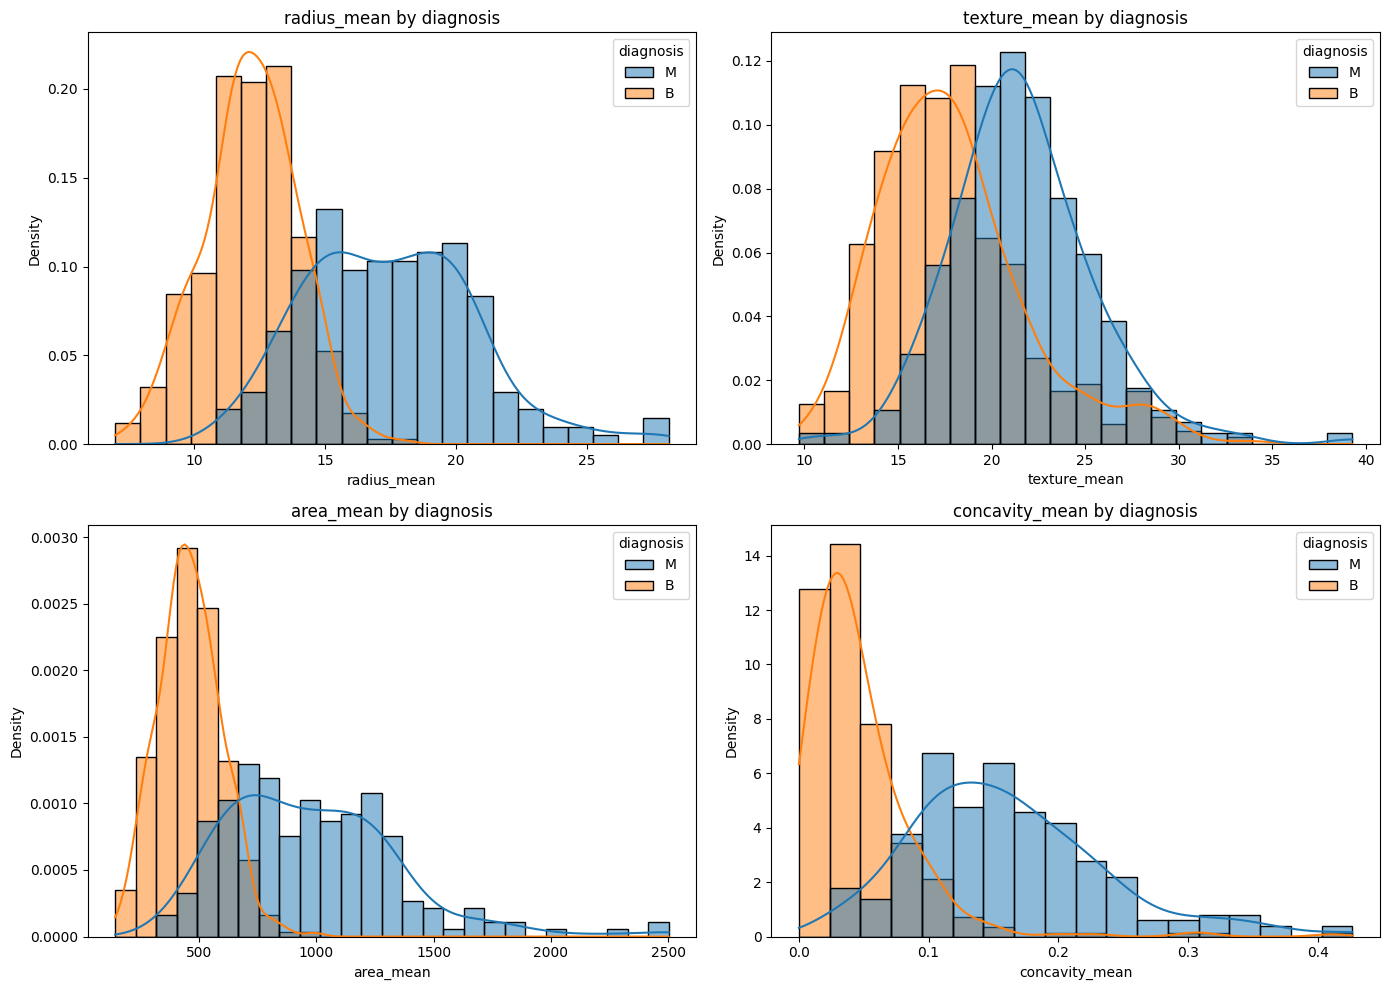

In [10]:
# Feature distributions by diagnosis
selected_features = ['radius_mean', 'texture_mean', 'area_mean', 'concavity_mean']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feature in zip(axes.flatten(), selected_features):
    sns.histplot(data=df, x=feature, hue='diagnosis', kde=True, stat='density', common_norm=False, ax=ax)
    ax.set_title(f'{feature} by diagnosis')
plt.tight_layout()
plt.show()


In [11]:
#Encode the target variable and remove the original diagnosis, id column
df["target"] = LabelEncoder().fit_transform(df["diagnosis"])
df.drop(columns=['diagnosis', 'id'], inplace=True)
df.head()


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


,corr_with_target
target,1.000000
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360


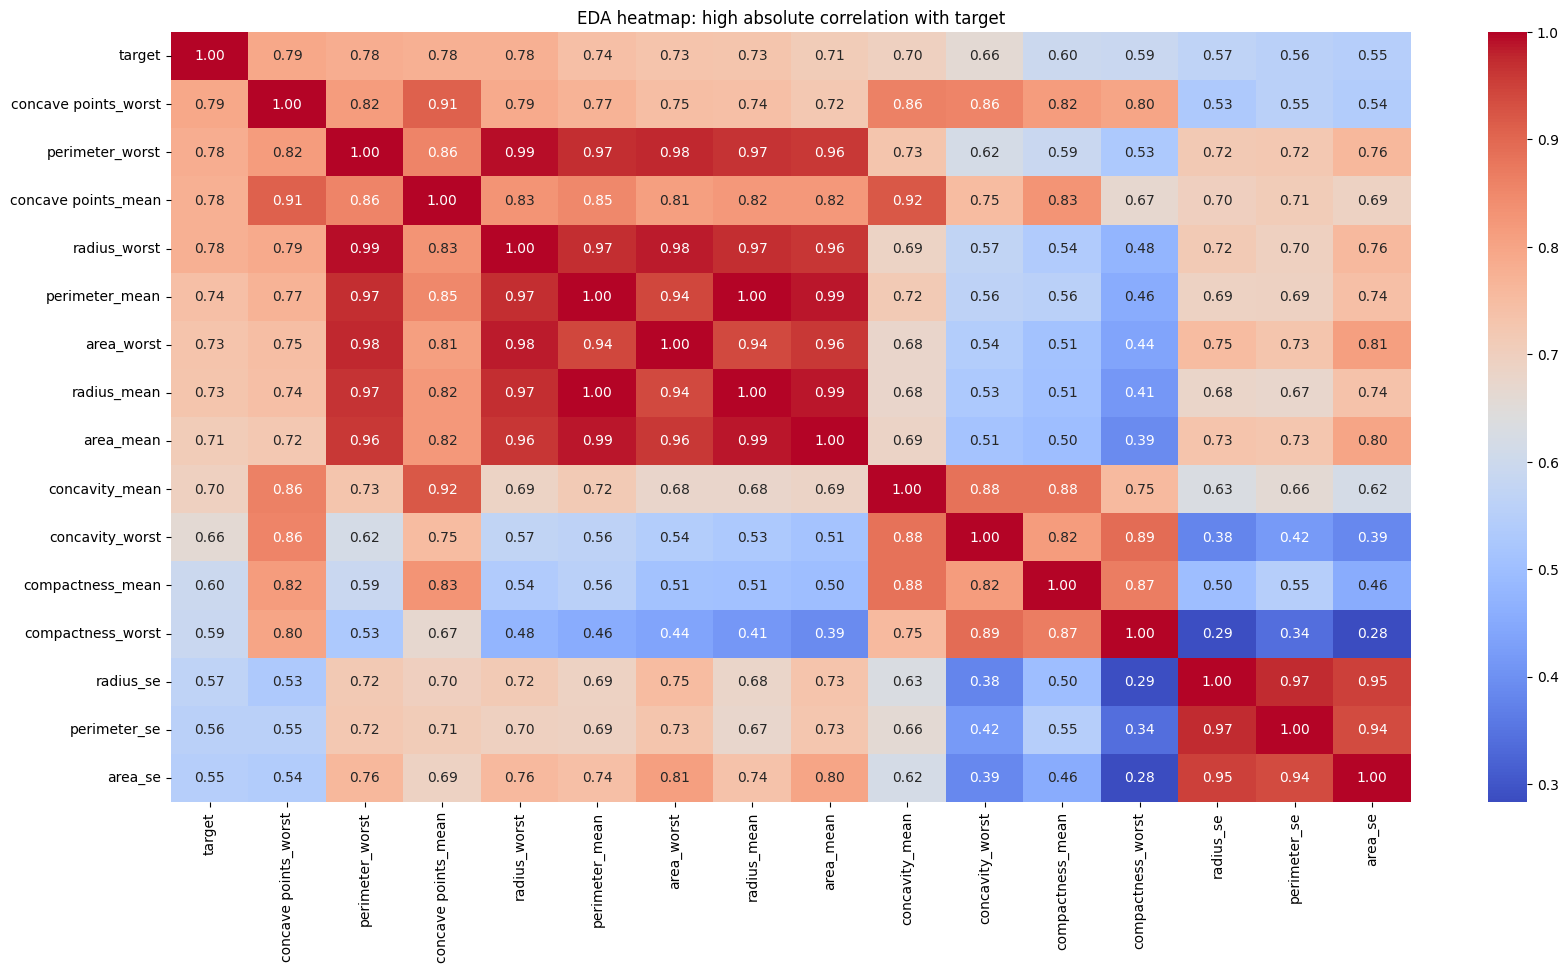

In [12]:
# Correlation for EDA only - do not use this full-dataset view for feature selection
corr_with_target = df.corr(numeric_only=True)['target'].sort_values(key=lambda s: s.abs(), ascending=False)
display(corr_with_target.to_frame(name='corr_with_target').head(15))

selected_eda = corr_with_target[corr_with_target.abs() > 0.5].index
plt.figure(figsize=(20, 10))
sns.heatmap(df[selected_eda].corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('EDA heatmap: high absolute correlation with target')
plt.show()


In [13]:
# Extra data-quality checks before modeling
print('Duplicate rows:', df.duplicated().sum())
display(df.describe().T[['mean', 'std', 'min', 'max']].head())


Duplicate rows: 0


,mean,std,min,max
radius_mean,14.127292,3.524049,6.98100,28.1100
texture_mean,19.289649,4.301036,9.71000,39.2800
perimeter_mean,91.969033,24.298981,43.79000,188.5000
area_mean,654.889104,351.914129,143.50000,2501.0000
smoothness_mean,0.096360,0.014064,0.05263,0.1634


## 3. Preprocess and Train-Only Feature Selection

In [14]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

all_features = df.drop(columns=['target'])
all_labels = df['target']

training_features, test_features, training_labels, test_labels = train_test_split(
    all_features, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)
validation_features, test_features, validation_labels, test_labels = train_test_split(
    test_features, test_labels, test_size=1/3, random_state=42, stratify=test_labels
)

# Feature selection is fit on training data only to avoid leakage
training_dataframe = training_features.copy()
training_dataframe['target'] = training_labels

training_correlations = training_dataframe.corr(numeric_only=True)['target'].drop('target')
selected_feature_names = training_correlations[training_correlations.abs() > 0.5].index.tolist()

# Remove a few highly collinear duplicates while keeping one representative feature
features_to_remove = [
    'perimeter_mean', 'area_mean',
    'perimeter_worst', 'area_worst',
    'perimeter_se', 'area_se',
]
selected_feature_names = [feature_name for feature_name in selected_feature_names if feature_name not in features_to_remove]

training_features = training_features[selected_feature_names]
validation_features = validation_features[selected_feature_names]
test_features = test_features[selected_feature_names]

feature_scaler = StandardScaler()
training_features_scaled = feature_scaler.fit_transform(training_features)
validation_features_scaled = feature_scaler.transform(validation_features)
test_features_scaled = feature_scaler.transform(test_features)

print('Selected features:', selected_feature_names)
print('Train/validation/test shapes:', training_features.shape, validation_features.shape, test_features.shape)


Selected features: ['radius_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'radius_se', 'radius_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst']
Train/validation/test shapes: (455, 9) (76, 9) (38, 9)


### Why neural networks need feature scaling
Neural networks are sensitive to the scale of input features because large-value features can dominate the gradient updates. This makes optimization slower and less stable. Scaling helps features stay in a similar range, so training converges faster and more smoothly.

### Why the scaler must be fit only on the training set
`StandardScaler` learns the mean and standard deviation from the data during `fit()`. If we fit it on the full dataset, information from the validation and test sets leaks into training. To avoid data leakage, we fit the scaler on `training_features` only, then use the same scaler to transform `validation_features` and `test_features`.

## 4. Model

In [15]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)

model = Sequential([
    Input(shape=(training_features_scaled.shape[1],)),
    # Dense(128, activation='relu'),
    # Dropout(0.3),
    # Dense(64, activation='relu'),
    # Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.summary()

model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])


2026-05-28 15:54:05.789495: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-05-28 15:54:05.789521: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-28 15:54:05.789527: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-05-28 15:54:05.789538: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-28 15:54:05.789545: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865 (3.38 KB)

 Trainable params: 865 (3.38 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training and Evaluation
Keras progress bar below shows `loss`, `accuracy`, `val_loss`, and `val_accuracy` after each epoch.

**Medical meaning of confusion matrix:**
- **True Positive (TP):** the patient has cancer and the model predicts cancer.
- **False Positive (FP):** the patient is healthy but the model predicts cancer.
- **True Negative (TN):** the patient is healthy and the model predicts healthy.
- **False Negative (FN):** the patient has cancer but the model predicts healthy. This is the most dangerous case in screening.

Epoch 1/100


2026-05-28 15:54:06.198109: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.1956 - loss: 1.1103 - val_accuracy: 0.1579 - val_loss: 0.7946
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4308 - loss: 0.7565 - val_accuracy: 0.8684 - val_loss: 0.5658
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7934 - loss: 0.5455 - val_accuracy: 0.9079 - val_loss: 0.4330
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8791 - loss: 0.4202 - val_accuracy: 0.9211 - val_loss: 0.3547
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9077 - loss: 0.3545 - val_accuracy: 0.9342 - val_loss: 0.3053
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9253 - loss: 0.3162 - val_accuracy: 0.9342 - val_loss: 0.2708
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9209 - loss: 0.2814 - val_accuracy: 0.9211 - val_loss: 0.2466
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9187 - loss: 0.2618 - val_accuracy: 0.9211 - val_l

,accuracy,loss,val_accuracy,val_loss
95,0.945055,0.141587,0.973684,0.080649
96,0.936264,0.145970,0.973684,0.080237
97,0.938462,0.129795,0.973684,0.079716
98,0.942857,0.141291,0.973684,0.079649
99,0.934066,0.140905,0.973684,0.079466


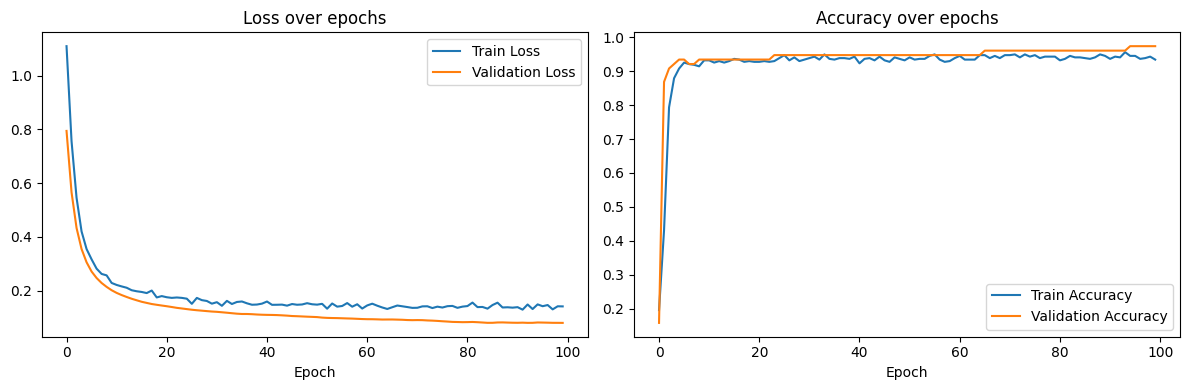

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9737 - loss: 0.0578
Test loss: 0.0578
Test accuracy: 0.9737


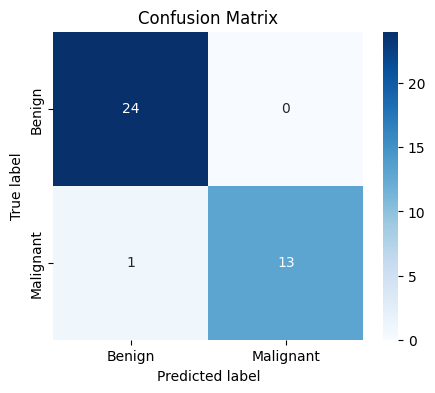

Precision: 1.0000
Precision measures how many predicted malignant cases are actually malignant.
Recall: 0.9286
Recall measures how many real malignant cases are detected by the model.
F1-score: 0.9630
F1-score balances Precision and Recall.

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        24
   Malignant       1.00      0.93      0.96        14

    accuracy                           0.97        38
   macro avg       0.98      0.96      0.97        38
weighted avg       0.97      0.97      0.97        38



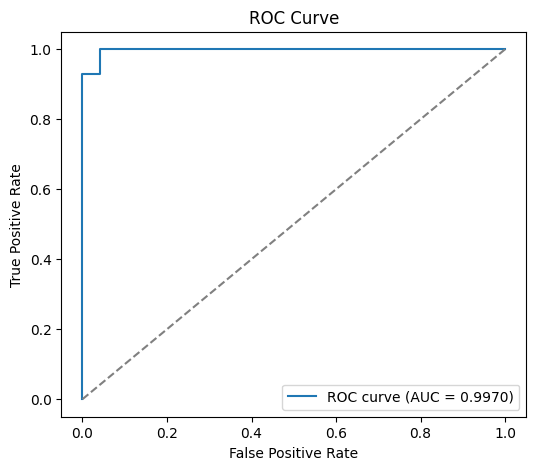

In [16]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    training_features_scaled, training_labels,
    validation_data=(validation_features_scaled, validation_labels),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

history_dataframe = pd.DataFrame(history.history)
display(history_dataframe.tail())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_dataframe['loss'], label='Train Loss')
axes[0].plot(history_dataframe['val_loss'], label='Validation Loss')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_dataframe['accuracy'], label='Train Accuracy')
axes[1].plot(history_dataframe['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

test_loss, test_accuracy = model.evaluate(test_features_scaled, test_labels, verbose=1)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

test_predicted_probabilities = model.predict(test_features_scaled, verbose=0).ravel()
test_predicted_labels = (test_predicted_probabilities >= 0.5).astype(int)

confusion_matrix_values = confusion_matrix(test_labels, test_predicted_labels)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix_values, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

precision = precision_score(test_labels, test_predicted_labels)
recall = recall_score(test_labels, test_predicted_labels)
f1_score_value = f1_score(test_labels, test_predicted_labels)
auc_score = roc_auc_score(test_labels, test_predicted_probabilities)

print(f'Precision: {precision:.4f}')
print('Precision measures how many predicted malignant cases are actually malignant.')
print(f'Recall: {recall:.4f}')
print('Recall measures how many real malignant cases are detected by the model.')
print(f'F1-score: {f1_score_value:.4f}')
print('F1-score balances Precision and Recall.')
print('\nClassification Report:')
print(classification_report(test_labels, test_predicted_labels, target_names=['Benign', 'Malignant']))

false_positive_rates, true_positive_rates, _ = roc_curve(test_labels, test_predicted_probabilities)
plt.figure(figsize=(6, 5))
plt.plot(false_positive_rates, true_positive_rates, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


### Training without feature scaling

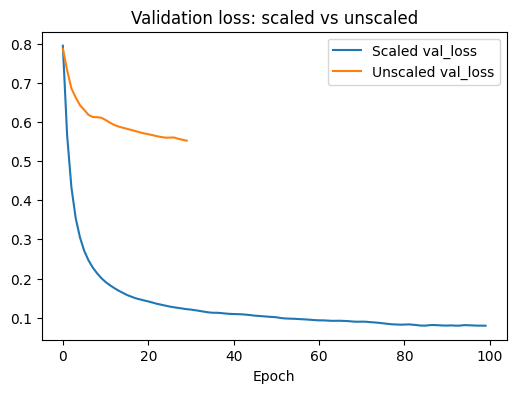

In [17]:
model_no_scale = Sequential([
    Input(shape=(training_features.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_no_scale.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

history_without_scaling = model_no_scale.fit(
    training_features, training_labels,
    validation_data=(validation_features, validation_labels),
    epochs=30,
    batch_size=32,
    verbose=0
)

plt.figure(figsize=(6, 4))
plt.plot(history.history['val_loss'], label='Scaled val_loss')
plt.plot(history_without_scaling.history['val_loss'], label='Unscaled val_loss')
plt.title('Validation loss: scaled vs unscaled')
plt.xlabel('Epoch')
plt.legend()
plt.show()


## 6. Discussion
**1. Which is more serious in cancer diagnosis: False Negative or False Positive?** 
False Negative is more serious. It means a patient who actually has cancer is predicted as healthy, so treatment may be delayed. In medical screening, this can lead to serious harm.

**2. Should we prioritize Precision or Recall? Why?**
Recall should usually be prioritized. In cancer screening, missing a real cancer case is more dangerous than sending a healthy patient for additional tests.

**3. What may happen if feature scaling is skipped?**
If scaling is skipped, the loss usually decreases more slowly and training may become less stable. Large-value features can dominate the gradient updates, so the model may converge to a worse solution.
